# 2. Ingeniería de Características (Feature Engineering)

En la ingeniería de características tradicional, solíamos mapear manualmente las columnas categóricas en DataFrames de pandas (por ejemplo, convirtiendo `Sex` de 'male'/'female' a 0/1, o aplicando One-Hot encoding manualmente en archivos intermedios como `data/titanic_feature.csv`).

Sin embargo, este enfoque manual tiene desventajas graves en producción:
- Propensión a errores por inconsistencias de categorías en tiempo real.
- Dificultad para mantener scripts paralelos de preprocesamiento.
- Riesgo de fuga de información (data leakage) al escalar los datos antes del split.

### Enfoque Moderno: Pipelines Automatizados

En lugar de crear archivos de datos preprocesados manualmente, utilizaremos el **ColumnTransformer** y **Pipeline** de `scikit-learn`. Este enfoque tiene grandes ventajas:
1. **Automatización Completa**: Cuando el frontend envía los datos crudos en formato JSON (ej. `Sex='female'`, `Embarked='C'`), el preprocesador empaquetado realiza la codificación One-Hot y el escalamiento estándar automáticamente en memoria.
2. **Previene Fugas**: El escalamiento estándar (`StandardScaler`) calcula la media y la desviación estándar **solo en el conjunto de entrenamiento**, y las aplica al de prueba, garantizando una correcta evaluación.
3. **Código Limpio**: Evita tener que escribir funciones de mapeo personalizadas en la API de Flask, haciendo que `app.py` sea sumamente conciso.

In [ ]:
# Demostración del Preprocesamiento del Pipeline
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Cargar los datos limpios
df = pd.read_csv('data/titanic_clean.csv')
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Definir columnas
numerical_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Sex', 'Embarked']

# Crear el transformador de columnas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Ajustar y transformar una muestra para ver los resultados mapeados
X_transformed = preprocessor.fit_transform(X)
print("Datos originales (primer registro):")
print(X.iloc[0])
print("\nDatos transformados por el preprocesador (primer registro):\n", X_transformed[0])

In [1]:
#importar prerequisitos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

#carga de datos
df = pd.read_csv('./data/titanic_clean.csv')


In [2]:
#labelencoder
from sklearn.preprocessing import LabelEncoder

# Datos categóricos de ejemplo
animales = ['gato', 'perro', 'pez', 'gato', 'perro']

# Crear una instancia de LabelEncoder
le = LabelEncoder()

# Ajustar y transformar los datos
animales_codificados = le.fit_transform(animales)

# Mostrar los datos codificados
print(animales_codificados)

# Si deseas ver cómo se mapean las etiquetas originales
print(list(le.classes_))

[0 1 2 0 1]
[np.str_('gato'), np.str_('perro'), np.str_('pez')]


In [4]:
#Codificación de Sex y Embarked
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Fit and transform on training data
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
461,0,3,1,34.0,0,0,8.0500,2
810,0,3,1,26.0,0,0,7.8875,2
651,1,2,0,18.0,0,1,23.0000,2
207,1,3,1,26.0,0,0,18.7875,0
663,0,3,1,36.0,0,0,7.4958,2


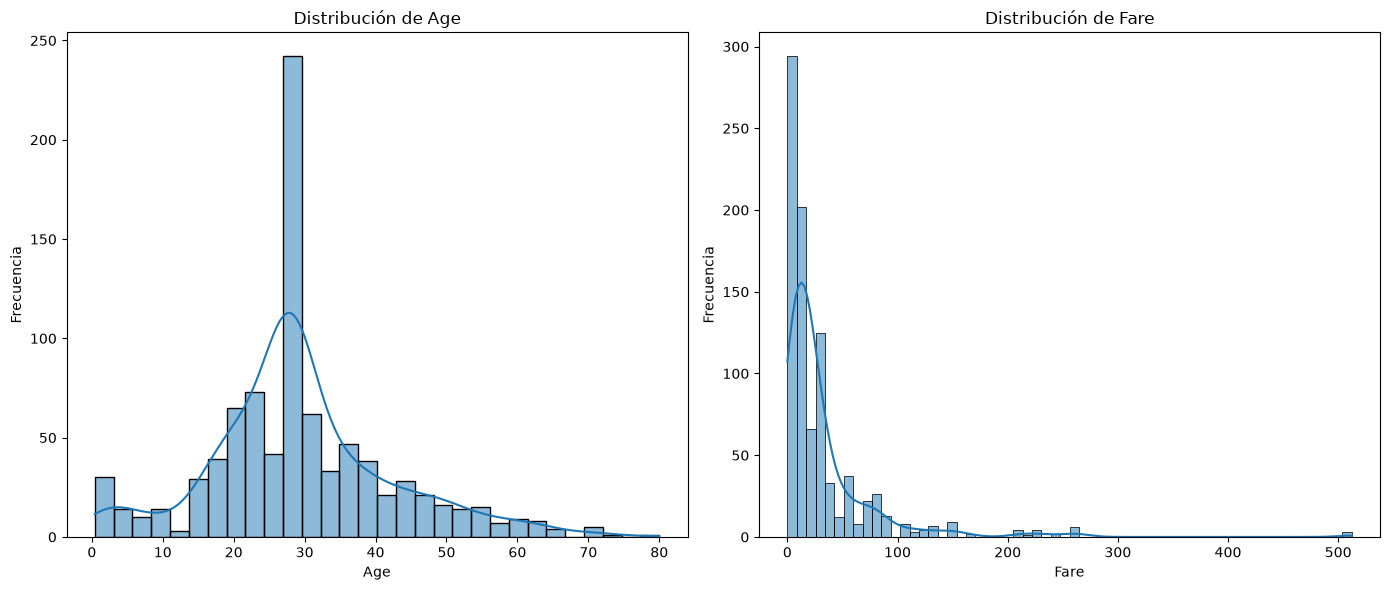

In [5]:
#normalización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

In [6]:
#Sckit Learn QuantileTransformer
qun_tra_age = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

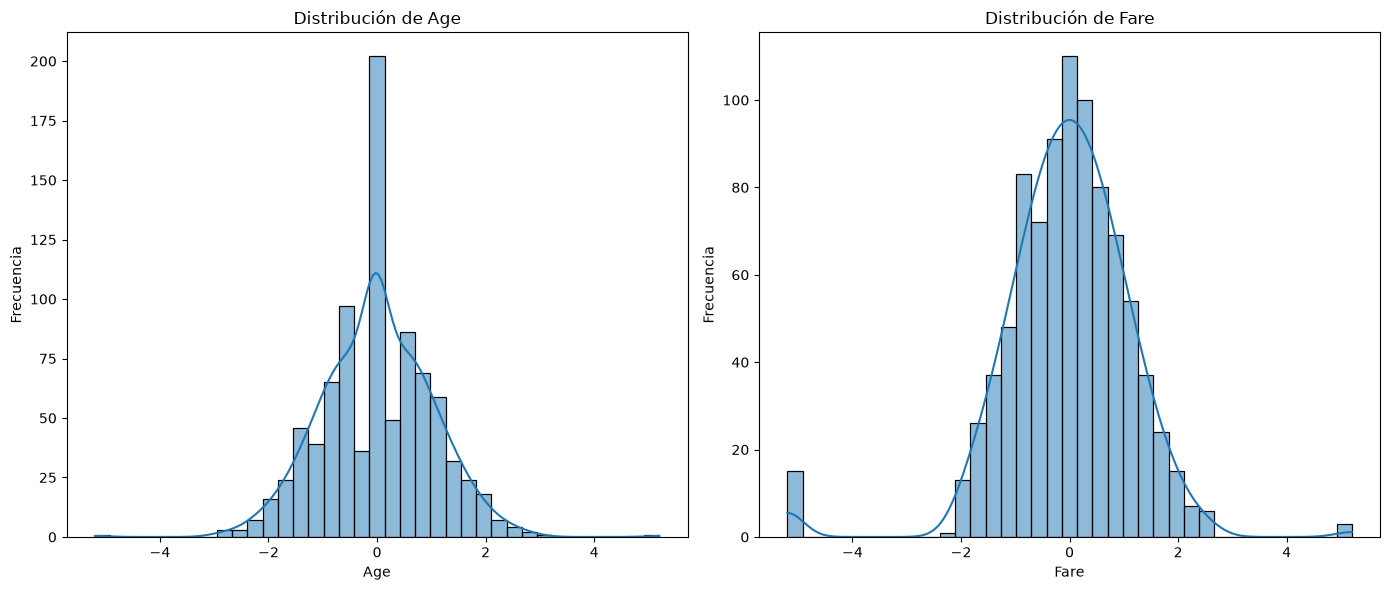

In [7]:
#volver a graficar para ver la distribución después de la transformación
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

In [8]:
#escalar
mms_pclass= MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

# Ejecutar transformaciones
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [9]:
#muestra
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
757,0,0.5,1.0,0.396662,0.000,0.0,0.479558,1.0
726,1,0.5,0.0,0.535318,0.375,0.0,0.522175,1.0
77,0,1.0,1.0,0.497826,0.000,0.0,0.448347,1.0
794,0,1.0,1.0,0.456270,0.000,0.0,0.428458,1.0
796,1,0.0,0.0,0.631239,0.000,0.0,0.532746,1.0


In [10]:
#guardado de datos preprocesados
df.to_csv('./data/titanic_procesado.csv', index=False)